# NYC Airbnb Price Prediction (2019)

End-to-end regression pipeline on the New York City Airbnb Open Data (2019). The goal is to predict nightly listing prices from location, room type, availability, and review features.

## Project Overview

This notebook follows a standard ML workflow: load and explore the data, split into train/test sets, preprocess features with scikit-learn pipelines, train baseline models, tune hyperparameters with cross-validation, and evaluate final performance on held-out test data.

## 1. Load Data

Import core libraries and read the NYC Airbnb CSV into a pandas DataFrame.

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
df = pd.read_csv("./AB_NYC_2019_1.csv")


## 2. Exploratory Data Analysis

Inspect the first rows, column types, and summary statistics to understand feature ranges and missing values.

In [ ]:
df.head()


,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


Distribution of listings across boroughs (`neighbourhood_group`).

In [ ]:
print(df.value_counts('neighbourhood_group'))


neighbourhood_group
Manhattan        21660
Brooklyn         20095
Queens            5666
Bronx             1090
Staten Island      373
Name: count, dtype: int64


Breakdown of listings by room type (`Entire home/apt`, `Private room`, `Shared room`).


In [ ]:
print(df.value_counts('room_type'))


room_type
Entire home/apt    25407
Private room       22319
Shared room         1158
Name: count, dtype: int64


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48884 entries, 0 to 48883
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48884 non-null  object 
 1   latitude                        48884 non-null  float64
 2   longitude                       48884 non-null  float64
 3   room_type                       48884 non-null  object 
 4   price                           48884 non-null  int64  
 5   minimum_nights                  48884 non-null  int64  
 6   number_of_reviews               48884 non-null  int64  
 7   reviews_per_month               38833 non-null  float64
 8   calculated_host_listings_count  48884 non-null  int64  
 9   availability_365                48884 non-null  int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 3.7+ MB


Column dtypes and non-null counts via `info()`.


In [ ]:
df.describe()


,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48884.000000,48884.000000,48884.000000,48884.000000,48884.000000,38833.000000,48884.000000,48884.000000
mean,40.728953,-73.952176,152.755053,7.029887,23.271991,1.373128,7.144628,112.779498
std,0.054532,0.046159,240.170260,20.512224,44.551331,1.680391,32.956185,131.627271
min,40.499790,-74.244420,10.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,40.690100,-73.983080,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,40.723080,-73.955685,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,40.763120,-73.936290,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


Histograms of numeric features to visualize value ranges and skew.

Descriptive statistics (mean, std, quartiles) for numeric columns.


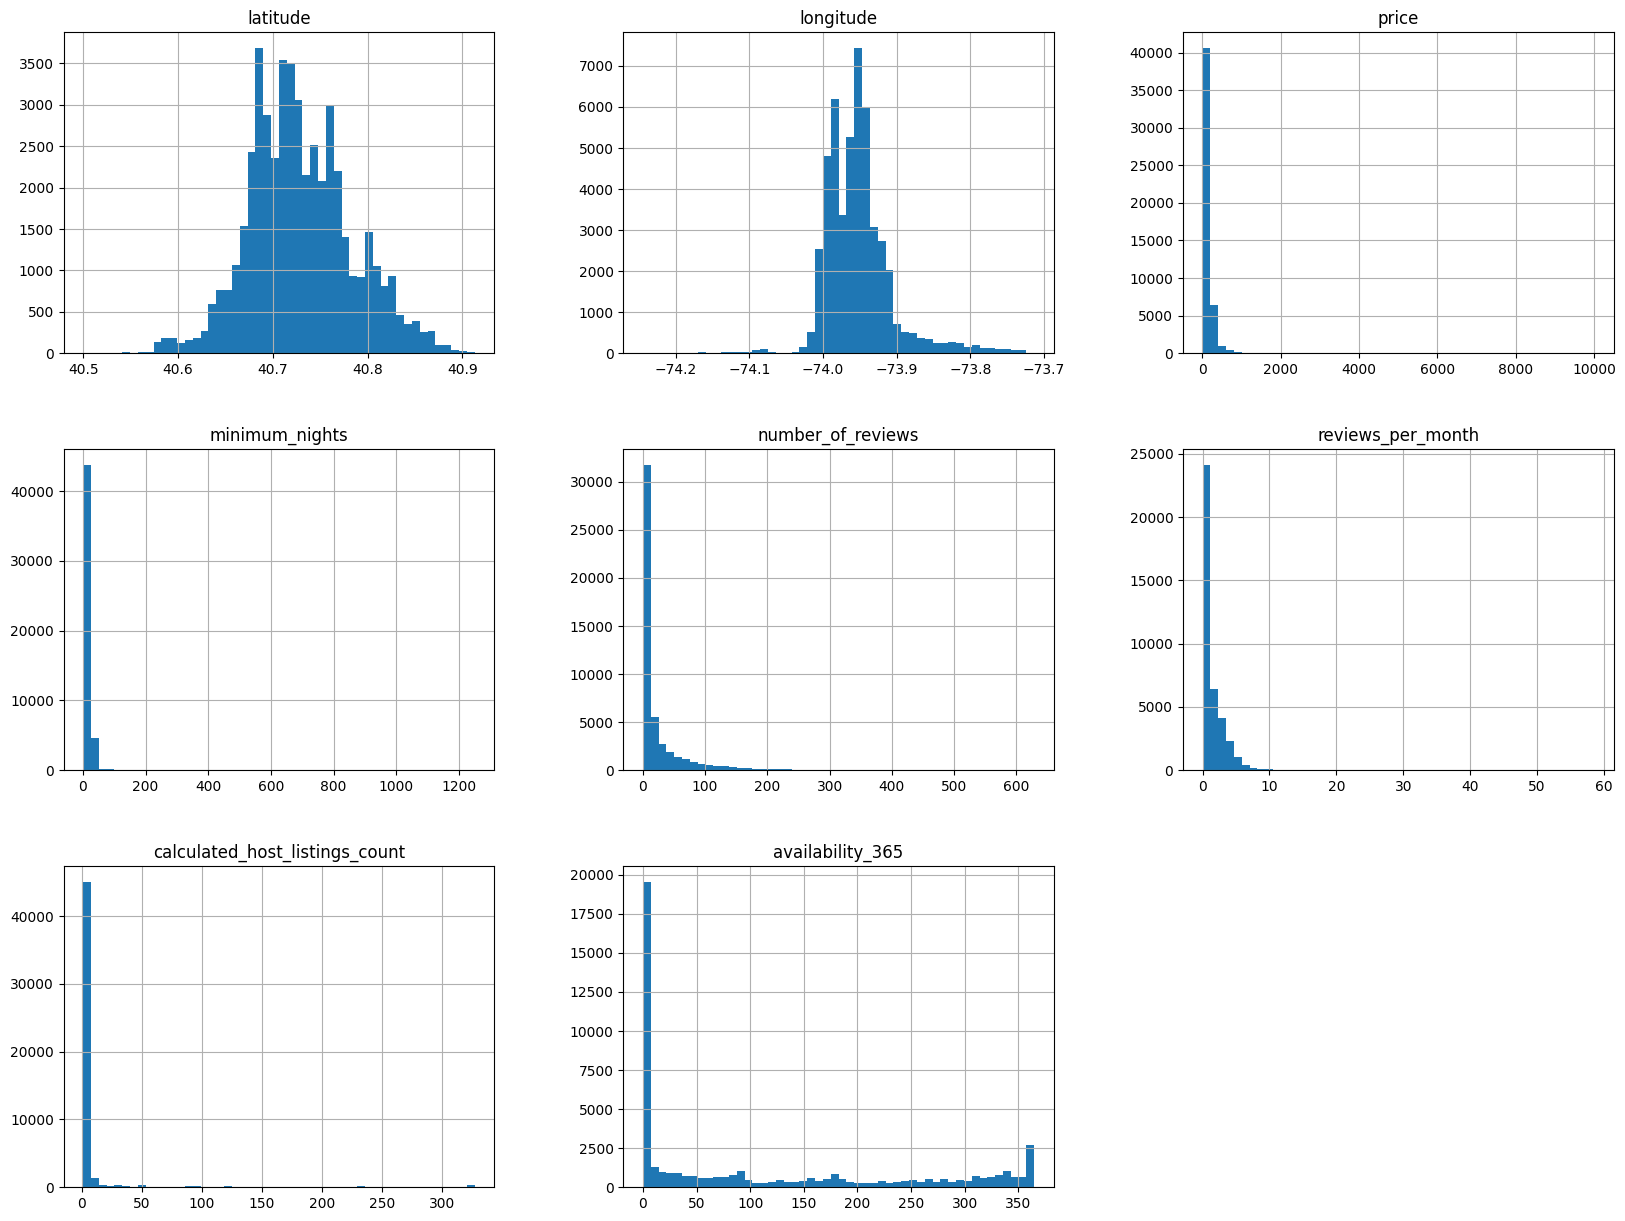

In [ ]:
import matplotlib.pyplot as plt
df.hist(bins=50, figsize=(20,15))
plt.show()


Compute pairwise correlations among numeric columns to see which features relate most strongly to price.

In [ ]:
corr_matrix = df.corr(numeric_only = True)


Sort features by correlation with the target (`price`). Longitude shows the strongest linear relationship.

In [ ]:
print(corr_matrix["price"].sort_values(ascending=False))


price                             1.000000
availability_365                  0.081847
calculated_host_listings_count    0.057462
minimum_nights                    0.042805
latitude                          0.033899
reviews_per_month                -0.030575
number_of_reviews                -0.047926
longitude                        -0.149954
Name: price, dtype: float64


Scatter matrix comparing price against longitude — the most price-correlated numeric feature.

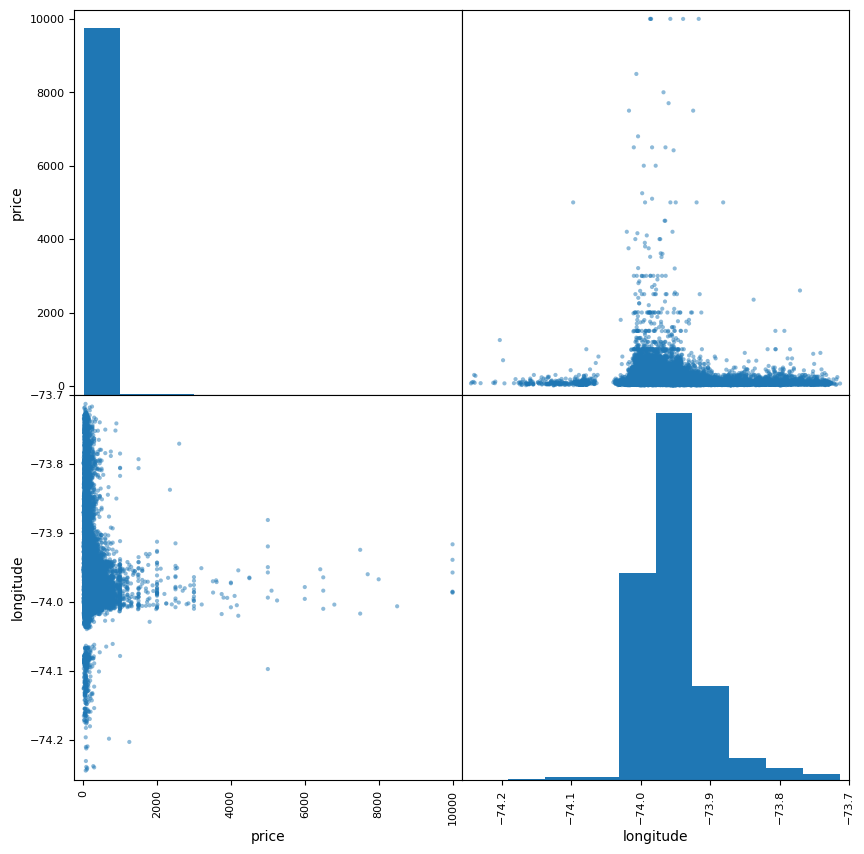

In [ ]:
from pandas.plotting import scatter_matrix
cols = ["price", "longitude"]
scatter_matrix(
    df[cols],
    figsize=(10, 10),
)
plt.show()


## 3. Train / Test Split

Hold out 20% of listings for final evaluation. Use stratified sampling on `neighbourhood_group` so borough proportions match the full dataset.

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df["neighbourhood_group"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]


In [ ]:
strat_test_set["neighbourhood_group"].value_counts()/len(strat_test_set)


neighbourhood_group
Manhattan        0.443081
Brooklyn         0.411067
Queens           0.115884
Bronx            0.022297
Staten Island    0.007671
Name: count, dtype: float64

Verify stratified split preserved borough proportions between train and full dataset.


In [ ]:
df["neighbourhood_group"].value_counts()/len(df)


neighbourhood_group
Manhattan        0.443090
Brooklyn         0.411075
Queens           0.115907
Bronx            0.022298
Staten Island    0.007630
Name: count, dtype: float64

In [ ]:
strat_test_set.head()


,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
43306,Manhattan,40.73571,-73.99694,Private room,425,1,0,NaN,2,353
2922,Queens,40.59684,-73.79449,Private room,35,2,201,3.28,2,88
39578,Manhattan,40.74692,-73.97548,Private room,70,30,1,0.16,1,172
45814,Manhattan,40.74751,-73.98051,Entire home/apt,300,30,0,NaN,8,355
7652,Manhattan,40.77260,-73.97928,Shared room,68,3,105,2.09,1,302


## 4. Feature Preparation

Separate features (`housing`) from the target (`housing_labels` = nightly price) in the training set.

In [ ]:
housing = strat_train_set.drop("price", axis=1)
housing_labels = strat_train_set["price"].copy()


In [ ]:
housing.head()


,neighbourhood_group,latitude,longitude,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
40275,Queens,40.68996,-73.74882,Private room,2,6,1.01,3,85
45402,Queens,40.76187,-73.82169,Private room,1,9,4.91,6,365
8028,Brooklyn,40.71178,-73.95684,Entire home/apt,15,27,0.68,1,173
43463,Queens,40.76308,-73.82215,Private room,2,1,1.00,2,0
43412,Manhattan,40.77961,-73.97821,Private room,2,3,1.13,1,61


In [ ]:
housing_labels.head()


40275    147
45402     69
8028      90
43463     63
43412    160
Name: price, dtype: int64

### 4.1 Missing Value Imputation

Listings with null numeric fields are imputed with column medians via `SimpleImputer`.

In [ ]:
sample_incomplete_rows = housing[housing.isnull().any(axis=1)].head()
sample_incomplete_rows


,neighbourhood_group,latitude,longitude,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
14678,Manhattan,40.71469,-73.99950,Entire home/apt,4,0,NaN,1,0
39014,Brooklyn,40.69076,-73.91296,Private room,30,0,NaN,103,236
9219,Brooklyn,40.67505,-73.98045,Private room,3,0,NaN,1,0
21857,Queens,40.76964,-73.92303,Private room,10,0,NaN,1,188
48717,Manhattan,40.72388,-73.98354,Entire home/apt,1,0,NaN,1,35


In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")


In [ ]:
housing_num = housing.drop(["neighbourhood_group", "room_type"], axis=1)


In [ ]:
imputer.fit(housing_num)


,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [ ]:
imputer.statistics_


array([ 40.72328, -73.95575,   3.     ,   5.     ,   0.71   ,   1.     ,
        44.     ])

In [ ]:
X = imputer.transform(housing_num)


In [ ]:
housing_tr = pd.DataFrame(X,columns=housing_num.columns, index=housing_num.index)


In [ ]:
housing_tr.describe()


,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,39107.000000,39107.000000,39107.000000,39107.000000,39107.000000,39107.000000,39107.000000
mean,40.729014,-73.952352,7.033600,23.376122,1.233795,7.313064,112.688087
std,0.054537,0.045933,20.247694,44.741109,1.498895,33.531340,131.647215
min,40.499790,-74.244420,1.000000,0.000000,0.010000,1.000000,0.000000
25%,40.690150,-73.983080,1.000000,1.000000,0.280000,1.000000,0.000000
50%,40.723280,-73.955750,3.000000,5.000000,0.710000,1.000000,44.000000
75%,40.763140,-73.936445,5.000000,24.000000,1.580000,2.000000,227.000000
max,40.913060,-73.712990,1250.000000,629.000000,27.950000,327.000000,365.000000


### 4.2 Categorical Encoding

Borough and room-type columns are one-hot encoded so tree and linear models can consume them.

In [ ]:
housing_cat = housing[["neighbourhood_group", "room_type"]]


,neighbourhood_group,room_type
40275,Queens,Private room
45402,Queens,Private room
8028,Brooklyn,Entire home/apt
43463,Queens,Private room
43412,Manhattan,Private room


In [ ]:
housing_cat.head(10)


,neighbourhood_group,room_type
40275,Queens,Private room
45402,Queens,Private room
8028,Brooklyn,Entire home/apt
43463,Queens,Private room
43412,Manhattan,Private room
18630,Brooklyn,Entire home/apt
48127,Manhattan,Entire home/apt
43135,Brooklyn,Entire home/apt
42151,Brooklyn,Private room
29627,Manhattan,Entire home/apt


In [ ]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)


In [ ]:
housing_cat_1hot


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 78214 stored elements and shape (39107, 8)>

In [ ]:
housing_cat_1hot.toarray()


array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 1., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.]], shape=(39107, 8))

In [ ]:
housing_cat_1hot.toarray()[0]


array([0., 0., 0., 1., 0., 0., 1., 0.])

In [ ]:
housing_cat_1hot.toarray().shape


(39107, 8)

In [ ]:
cat_encoder.categories_


[array(['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island'],
       dtype=object),
 array(['Entire home/apt', 'Private room', 'Shared room'], dtype=object)]

### 4.3 Numeric Preprocessing Pipeline

Build a reusable pipeline: custom column selector → median imputation → standard scaling.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


Custom transformer to subset numeric columns by index for the pipeline.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
lat_ix, lon_ix, min_nights_ix, reviews_ix, reviews_month_ix, host_ix, avail_ix = range(len(housing_num.columns))
class AirbnbAttrAdder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        availability_ratio = X[:, avail_ix] / 365.0
        min_nights_ratio = X[:, min_nights_ix] / 365.0
        reviews_per_year = np.nan_to_num(X[:, reviews_month_ix], nan=0.0) * 12.0
        reviews_per_available_day = reviews_per_year / np.where(X[:, avail_ix]==0, 1, X[:, avail_ix])
        host_listings_log = np.log1p(X[:, host_ix])
        return np.c_[X, availability_ratio, min_nights_ratio, reviews_per_year, reviews_per_available_day, host_listings_log]
attr_adder = AirbnbAttrAdder()
housing_extra_attribs_array = attr_adder.transform(housing_num.values)
housing_extra_attribs = pd.DataFrame(
    housing_extra_attribs_array,
    columns=list(housing_num.columns) + [
        "availability_ratio",
        "min_nights_ratio",
        "reviews_per_year",
        "reviews_per_available_day",
        "host_listings_log"
    ],
    index=housing.index
)
housing_extra_attribs.head()


,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,availability_ratio,min_nights_ratio,reviews_per_year,reviews_per_available_day,host_listings_log
40275,40.68996,-73.74882,2.0,6.0,1.01,3.0,85.0,0.232877,0.005479,12.12,0.142588,1.386294
45402,40.76187,-73.82169,1.0,9.0,4.91,6.0,365.0,1.000000,0.002740,58.92,0.161425,1.945910
8028,40.71178,-73.95684,15.0,27.0,0.68,1.0,173.0,0.473973,0.041096,8.16,0.047168,0.693147
43463,40.76308,-73.82215,2.0,1.0,1.00,2.0,0.0,0.000000,0.005479,12.00,12.000000,1.098612
43412,40.77961,-73.97821,2.0,3.0,1.13,1.0,61.0,0.167123,0.005479,13.56,0.222295,0.693147


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('attribs_adder', AirbnbAttrAdder()),
    ('imputer2', SimpleImputer(strategy="median")),
    ('std_scaler', StandardScaler()),
])
housing_num_tr = num_pipeline.fit_transform(housing_num)
housing_extra_attribs = pd.DataFrame(
    housing_num_tr,
    columns=list(housing_num.columns) + [
        "availability_ratio",
        "min_nights_ratio",
        "reviews_per_year",
        "reviews_per_available_day",
        "host_listings_log"
    ],
    index=housing.index
)
housing_num_tr


array([[-0.71611725,  4.43117559, -0.24860434, ..., -0.14930885,
        -0.40886414,  0.34315508],
       [ 0.60245943,  2.84469698, -0.29799331, ...,  2.45264051,
        -0.40591407,  0.98845821],
       [-0.31601513, -0.0977016 ,  0.3934523 , ..., -0.3694738 ,
        -0.42380846, -0.45612553],
       ...,
       [ 0.28615505, -0.49045683,  1.13428688, ..., -0.7497587 ,
        -0.43053089,  3.32280961],
       [-0.92111916,  0.7653149 , -0.29799331, ...,  5.74844302,
        -0.35275532,  0.01142366],
       [-0.52578453,  0.51516204, -0.24860434, ...,  0.51118599,
        -0.36285446, -0.45612553]], shape=(39107, 12))

### 4.4 Full Preprocessing Pipeline

Combine numeric and categorical branches with `ColumnTransformer`, then fit on the training set to produce `housing_prepared`.

In [ ]:
from sklearn.compose import ColumnTransformer
num_attribs = list(housing_num)
cat_attribs = ["neighbourhood_group"]
full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", OneHotEncoder(), cat_attribs),
    ])
housing_prepared = full_pipeline.fit_transform(housing)


In [ ]:
housing_prepared


array([[-0.71611725,  4.43117559, -0.24860434, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.60245943,  2.84469698, -0.29799331, ...,  0.        ,
         1.        ,  0.        ],
       [-0.31601513, -0.0977016 ,  0.3934523 , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.28615505, -0.49045683,  1.13428688, ...,  1.        ,
         0.        ,  0.        ],
       [-0.92111916,  0.7653149 , -0.29799331, ...,  0.        ,
         0.        ,  0.        ],
       [-0.52578453,  0.51516204, -0.24860434, ...,  0.        ,
         0.        ,  0.        ]], shape=(39107, 17))

## 5. Baseline Models

Train a linear regressor and a decision tree as initial benchmarks on the preprocessed training data.

### 5.1 Linear Regression

Fit ordinary least-squares regression and measure training error.

In [ ]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)
print("Predictions:", lin_reg.predict(some_data_prepared))


Predictions: [ 17.04321206  88.29482247 139.64468146  30.69006024 195.54761872]


In [ ]:
print("Labels:", list(some_labels))


Labels: [147, 69, 90, 63, 160]


In [ ]:
from sklearn.metrics import mean_squared_error
housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse


np.float64(236.9723632711642)

In [ ]:
from sklearn.metrics import mean_absolute_error
lin_mae = mean_absolute_error(housing_labels, housing_predictions)
lin_mae


84.17818647389448

**Metric choice:** MAE (mean absolute error) is used throughout because it is interpretable in dollars. RMSE penalizes large errors more heavily due to squaring.

### 5.2 Decision Tree Regressor

A single decision tree captures non-linear patterns but tends to overfit on training data.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_labels)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [ ]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_absolute_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse


np.float64(0.0)

## 6. Model Tuning

Compare models with 10-fold cross-validation, then search hyperparameter space with grid and randomized search.

### 6.1 Cross-Validation

10-fold CV with negative MAE scoring to estimate out-of-sample performance for each baseline model.

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
                         scoring="neg_mean_absolute_error", cv=10)
tree_mae_scores = scores
print(tree_mae_scores)


[-100.77806188 -112.36742521 -105.83354641 -101.14420864  -99.88212733
 -102.29838916  -93.86806443 -100.4797954  -114.4544757  -101.64322251]


In [ ]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())
display_scores(tree_mae_scores)


Scores: [100.77806188 112.36742521 105.83354641 101.14420864  99.88212733
 102.29838916  93.86806443 100.4797954  114.4544757  101.64322251]
Mean: 103.27493166692932
Standard deviation: 5.800048807335685


In [ ]:
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
                             scoring="neg_mean_absolute_error", cv=10)
lin_mae_scores = -lin_scores
display_scores(lin_mae_scores)


Scores: [83.41149758 88.41403775 86.46229776 81.45722024 83.57696473 83.62942836
 82.33202206 83.54700635 85.54970924 83.73586006]
Mean: 84.21160441190297
Standard deviation: 1.9412867828601548


### 6.2 Random Forest

Ensemble of decision trees to reduce overfitting while capturing non-linear feature interactions.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(housing_prepared, housing_labels)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
housing_predictions = forest_reg.predict(housing_prepared)
forest_mae = mean_absolute_error(housing_labels, housing_predictions)
forest_mae


29.287522438438135

In [ ]:
from sklearn.model_selection import cross_val_score
forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
                                scoring="neg_mean_absolute_error", cv=10)
forest_mae_scores = -forest_scores
display_scores(forest_mae_scores)


Scores: [79.36778062 82.97735362 81.48975965 75.27206085 77.39716185 76.74985937
 76.11484019 77.82485422 81.4723734  80.25883887]
Mean: 78.89248826557136
Standard deviation: 2.4692122893200272


Cross-validation confirms random forest outperforms linear regression and the single decision tree.

In [ ]:
scores = cross_val_score(lin_reg, housing_prepared, housing_labels, scoring="neg_mean_absolute_error", cv=10)
pd.Series(-scores).describe()


count    10.000000
mean     84.211604
std       2.046296
min      81.457220
25%      83.445375
50%      83.603197
75%      85.096247
max      88.414038
dtype: float64

In [ ]:
pd.Series(forest_mae_scores).describe()


count    10.000000
mean     78.892488
std       2.602778
min      75.272061
25%      76.911685
50%      78.596317
75%      81.168990
max      82.977354
dtype: float64

In [ ]:
pd.Series(tree_mae_scores).describe()


count     10.000000
mean    -103.274932
std        6.113788
min     -114.454476
25%     -104.949757
50%     -101.393716
75%     -100.554362
max      -93.868064
dtype: float64

In [ ]:
pd.Series(lin_mae_scores).describe()


count    10.000000
mean     84.211604
std       2.046296
min      81.457220
25%      83.445375
50%      83.603197
75%      85.096247
max      88.414038
dtype: float64

### 6.3 Grid Search

Exhaustive search over `n_estimators`, `max_features`, and `bootstrap` for the random forest regressor.

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
  ]
forest_reg = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(housing_prepared, housing_labels)


,estimator,RandomForestR...ndom_state=42)
,param_grid,"[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,30


In [ ]:
grid_search.best_params_


{'max_features': 4, 'n_estimators': 30}

In [ ]:
grid_search.best_estimator_


,n_estimators,30
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,4
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
cvres = grid_search.cv_results_
print(cvres)


{'mean_fit_time': array([0.09236727, 0.27048798, 0.82161002, 0.13750525, 0.44960184,
       1.37225266, 0.19340658, 0.62338057, 1.95882745, 0.24746857,
       0.8453218 , 2.4884016 , 0.13764901, 0.43255944, 0.16367197,
       0.55751624, 0.21117525, 0.70159936]), 'std_fit_time': array([0.02242816, 0.00309922, 0.0200055 , 0.00321915, 0.00801463,
       0.0716385 , 0.00375064, 0.00776396, 0.06190521, 0.00642844,
       0.02653318, 0.07462574, 0.01639137, 0.00565759, 0.0020641 ,
       0.0036112 , 0.00511305, 0.01099848]), 'mean_score_time': array([0.00520678, 0.01762671, 0.04968562, 0.00544848, 0.01788573,
       0.04840426, 0.00544744, 0.01688766, 0.05084515, 0.00524321,
       0.01738172, 0.05050263, 0.00675054, 0.0201766 , 0.00666361,
       0.01948347, 0.00667744, 0.022473  ]), 'std_score_time': array([0.00025632, 0.00202342, 0.00363724, 0.0003519 , 0.00145949,
       0.00067086, 0.00049677, 0.00058647, 0.00392445, 0.00039764,
       0.00084826, 0.00186415, 0.00069569, 0.00040542, 0.

In [ ]:
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)


258.2871379954264 {'max_features': 2, 'n_estimators': 3}
239.19898199425361 {'max_features': 2, 'n_estimators': 10}
231.64354963121636 {'max_features': 2, 'n_estimators': 30}
254.70428301942383 {'max_features': 4, 'n_estimators': 3}
237.05181881690086 {'max_features': 4, 'n_estimators': 10}
230.81550966071842 {'max_features': 4, 'n_estimators': 30}
262.4803661693025 {'max_features': 6, 'n_estimators': 3}
239.51063419675575 {'max_features': 6, 'n_estimators': 10}
232.05697572495535 {'max_features': 6, 'n_estimators': 30}
254.81059510738626 {'max_features': 8, 'n_estimators': 3}
239.10441761377356 {'max_features': 8, 'n_estimators': 10}
233.33525951851607 {'max_features': 8, 'n_estimators': 30}
262.9617663598808 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
239.20514672880012 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
256.51557949583616 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
240.93358026104954 {'bootstrap': False, 'max_features': 3, 'n_es

In [ ]:
pd.DataFrame(grid_search.cv_results_)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_n_estimators,param_bootstrap,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.086717,0.007010,0.005777,0.000504,2,3,NaN,"{'max_features': 2, 'n_estimators': 3}",-73590.186397,-69668.741299,...,-66712.245654,7183.743677,15,-16454.201360,-18179.821313,-19245.692283,-22329.921136,-18031.071516,-18848.141522,1955.813932
1,0.276508,0.011913,0.016976,0.001910,2,10,NaN,"{'max_features': 2, 'n_estimators': 10}",-63570.940214,-62972.526961,...,-57216.152987,11085.105889,7,-10989.378496,-11473.358141,-11449.970155,-12625.084610,-10232.621997,-11354.082680,778.402229
2,0.837201,0.037873,0.052798,0.002687,2,30,NaN,"{'max_features': 2, 'n_estimators': 30}",-61370.881216,-58617.014242,...,-53658.734086,11528.464927,2,-8083.656602,-8930.296800,-9438.715031,-10436.416026,-8997.635031,-9177.343898,767.210133
3,0.136734,0.003035,0.005514,0.000387,4,3,NaN,"{'max_features': 4, 'n_estimators': 3}",-72896.395040,-72460.873619,...,-64874.271788,12080.137672,12,-17877.086268,-18364.493403,-20615.766424,-19468.856887,-17746.995507,-18814.639698,1085.685023
4,0.448262,0.014351,0.016654,0.000619,4,10,NaN,"{'max_features': 4, 'n_estimators': 10}",-64357.497848,-64536.034947,...,-56193.564804,12432.390741,5,-11448.122695,-11904.259789,-11381.404119,-12381.613642,-10989.283005,-11620.936650,478.566257
5,1.327337,0.024198,0.048642,0.000731,4,30,NaN,"{'max_features': 4, 'n_estimators': 30}",-62409.919603,-59237.233007,...,-53275.799500,11900.501389,1,-8213.581692,-9061.830769,-9551.435425,-10356.169549,-9044.896392,-9245.582766,702.284114
6,0.195269,0.006219,0.005388,0.000491,6,3,NaN,"{'max_features': 6, 'n_estimators': 3}",-73838.894045,-80208.557701,...,-68895.942624,11834.157717,16,-18817.096312,-19400.121389,-21699.120238,-20550.949353,-16737.639104,-19440.985279,1675.122777
7,0.648604,0.019620,0.020377,0.007654,6,10,NaN,"{'max_features': 6, 'n_estimators': 10}",-64787.461394,-66911.889853,...,-57365.343893,11962.620338,9,-11687.516051,-12057.443453,-11762.693412,-12213.869772,-10383.456083,-11620.995754,647.764434
8,1.864439,0.018600,0.048732,0.000975,6,30,NaN,"{'max_features': 6, 'n_estimators': 30}",-61712.747953,-62210.650874,...,-53850.439983,12187.133635,3,-8388.487376,-9110.749836,-9745.451799,-10399.559848,-9022.030306,-9333.255833,684.962400
9,0.250616,0.011095,0.004936,0.000103,8,3,NaN,"{'max_features': 8, 'n_estimators': 3}",-77745.301713,-71817.561039,...,-64928.439379,12842.581271,13,-19998.402113,-17925.435260,-20309.680514,-21098.052675,-18243.954250,-19515.104962,1225.848588


### 6.4 Randomized Search

Sample hyperparameters from broader distributions — often finds strong configs with fewer training runs than grid search.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_distribs = {
        'n_estimators': randint(low=1, high=200),
        'max_features': randint(low=1, high=8),
    }
forest_reg = RandomForestRegressor(random_state=42)
rnd_search = RandomizedSearchCV(forest_reg, param_distributions=param_distribs,
                                n_iter=10, cv=5, scoring='neg_mean_absolute_error', random_state=42)
rnd_search.fit(housing_prepared, housing_labels)


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_features': <scipy.stats....t 0x12722f230>, 'n_estimators': <scipy.stats....t 0x1352e6350>}"
,n_iter,10
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
cvres = rnd_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(-mean_score, params)


77.4613039959199 {'max_features': 7, 'n_estimators': 180}
79.87687233002671 {'max_features': 5, 'n_estimators': 15}
77.09659006688477 {'max_features': 3, 'n_estimators': 72}
79.16557149397694 {'max_features': 5, 'n_estimators': 21}
77.56019892544772 {'max_features': 7, 'n_estimators': 122}
77.12050824520009 {'max_features': 3, 'n_estimators': 75}
76.962410531379 {'max_features': 3, 'n_estimators': 88}
77.39232161232152 {'max_features': 5, 'n_estimators': 100}
76.7057766181816 {'max_features': 3, 'n_estimators': 150}
91.5117541098154 {'max_features': 5, 'n_estimators': 2}


Randomized search achieved better cross-validated MAE than the grid search in this run.

Extract feature importances from the best random forest to see which attributes drive price predictions.

In [ ]:
feature_importances = rnd_search.best_estimator_.feature_importances_
feature_importances


array([0.20186998, 0.22354373, 0.06944747, 0.04134664, 0.04618629,
       0.0330934 , 0.06603568, 0.06473761, 0.06303156, 0.05049253,
       0.07737331, 0.03098644, 0.00056539, 0.00784826, 0.01614826,
       0.00608289, 0.00121057])

Map importance scores to feature names (including one-hot encoded borough columns).

In [ ]:
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + cat_one_hot_attribs
sorted(zip(feature_importances, attributes), reverse=True)


[(np.float64(0.223543727409228), 'longitude'),
 (np.float64(0.20186998162970393), 'latitude'),
 (np.float64(0.07737330971273768), 'Queens'),
 (np.float64(0.0694474687304134), 'minimum_nights'),
 (np.float64(0.06603568035791883), 'availability_365'),
 (np.float64(0.06473760814065159), 'Bronx'),
 (np.float64(0.06303155562233236), 'Brooklyn'),
 (np.float64(0.05049253092170021), 'Manhattan'),
 (np.float64(0.04618629306930281), 'reviews_per_month'),
 (np.float64(0.04134663892784842), 'number_of_reviews'),
 (np.float64(0.033093399584262294), 'calculated_host_listings_count'),
 (np.float64(0.030986443202259656), 'Staten Island')]

## 7. Test Set Evaluation

Apply the best model from grid search to the held-out test set and report final MAE.

In [ ]:
final_model = grid_search.best_estimator_
X_test = strat_test_set.drop("price", axis=1)
y_test = strat_test_set["price"].copy()
X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)
final_mae = mean_absolute_error(y_test, final_predictions)
final_rmae = np.sqrt(final_mse)


In [ ]:
final_mae


79.02356948848204

## 8. Error Analysis

Examine prediction residuals (predicted − actual) to understand where the model succeeds and where it struggles.

In [ ]:
diff = final_predictions - y_test


In [ ]:
pd.Series(diff).describe()


count    9777.000000
mean        1.783735
std       210.030284
min     -9893.233333
25%       -20.666667
50%        18.966667
75%        53.600000
max      1770.200000
Name: price, dtype: float64

<Axes: >

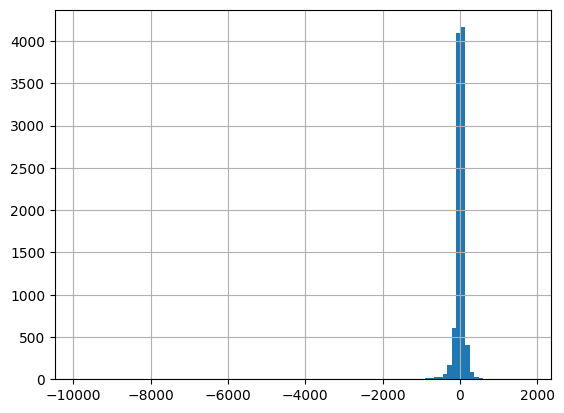

In [ ]:
pd.Series(diff).hist(bins=100)


Focus on the middle 95% of residuals to exclude extreme outliers from the distribution view.

In [ ]:
import pandas as pd
sorted_series = pd.Series(diff).sort_values()
total_elements = len(sorted_series)
start_index = int(total_elements * 0.025)
end_index = int(total_elements * 0.975)
middle_95_percent_data = sorted_series[start_index:end_index]
middle_95_percent_data.describe()


count    9288.000000
mean       11.825221
std        72.307037
min      -284.600000
25%       -17.508333
50%        18.966667
75%        51.241667
max       204.666667
Name: price, dtype: float64

<Axes: >

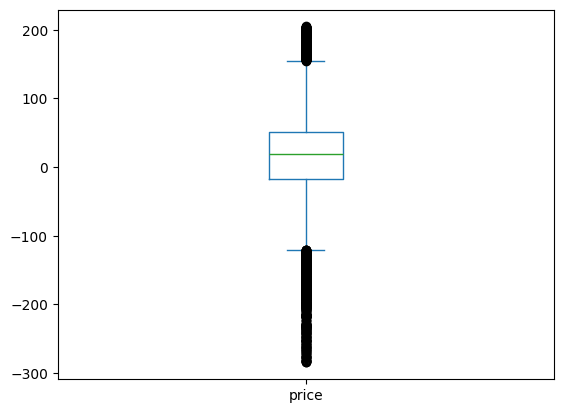

In [ ]:
middle_95_percent_data.plot.box()


Absolute errors for the central 95% of predictions — most listings are within ~$29 of the true price.

In [ ]:
abs(middle_95_percent_data).describe()


count    9288.000000
mean       54.301441
std        49.185308
min         0.000000
25%        18.525000
50%        40.000000
75%        74.475000
max       284.600000
Name: price, dtype: float64

<Axes: >

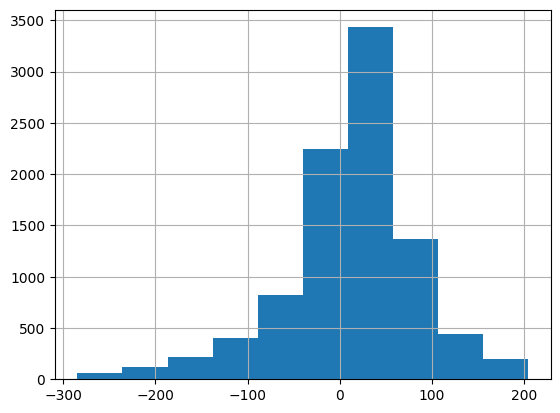

In [ ]:
middle_95_percent_data.hist()
